# Group member
| Name          | Student ID |
|---------------|------------|
| Yash Joshi    | -  |
| Ishani Maitra | -  |
| LimFangYi     | -  |
| TingHeng      | -  |


#Table of Content
- **[Course Project: An Arbitrage-Free Smile Interpolator](#scrollTo=8pv76DaAD2fp)**
    - **[Objectives](#scrollTo=9Kucrgn3-UZA)**
        - [Smile Arbitrage](#scrollTo=9Kucrgn3-UZA)
        - [When Could Smile Arbitrage Happen?](#scrollTo=9Kucrgn3-UZA)
        - [Arbitrage Free Smile (Based on [Fengler 2009])](#scrollTo=9Kucrgn3-UZA)
    - **[Inputs to our problem](#scrollTo=2zO0ulZ7DmFY)**
        - [Problem Definition](#scrollTo=2zO0ulZ7DmFY)
    - **[Implementation](#scrollTo=l5XQhoD9Du0c)**
        - **[SmileAF](#scrollTo=ZFKEdIAi-UZa)**
            - [High Level Overview](#scrollTo=fzSXR1tWSBCl)
            - [Inputs and Constraints](#scrollTo=bL-tPDBVIebE)
            - [Your test cases with SmileAF](#scrollTo=ExxyKDsF-UZw)
    - **[Conclusion and Improvements](#scrollTo=NUeeZbFQQK-7)**

# Course Project: An Arbitrage-Free Smile Interpolator
*Project report should be submitted as a Jupyter notebook (.ipynb). Each project group should have 1 to 3 members. The report should be written based on this notebook. Please make your formulas and code, test results, observations, intermediate results, improvements made/suggested (optional), and conclusions clear.*

## 1. Objectives
  - Implement an arbitrage free smile interpolator SmileAF.
  - Use the arbitrage free smile interpolator to construct local volatility model
  - Use PDE with local volatility model to price a given set of European options (strike in delta $\times$ maturity)
  - Compare the price errors of arbitrage-free smile interpolator and the cubic spline smile interpolator
  - Open questions for bonus points: improve the algorithms in terms of precision and efficiency (smile interpolation, implied vol, local vol, PDE, calibration report). One area to consider for improvement is the construction of the tails (wings).


### Smile Arbitrage
1. European call prices are monotonically decreasing with respect to the strike:

    \begin{align}
    C(S_0, K_1, T, \sigma(K_1), r, q) \geq C(S_0, K_2, T, \sigma(K_2), r, q) ~\text{for}~K_1 < K_2
    \end{align}


2. The European call price as a function of strike has to be convex every where: for any three points $K_1 < K_2 < K_3$

    \begin{align*}
    \frac{C(K_2) - C(K_1) } {K_2 - K_1} < \frac{C(K_3) - C(K_2) } {K_3 - K_2}
    \end{align*}

    or

    \begin{align}
    C(K_2)  < C(K_3)\frac{K_2 - K_1} {K_3 - K_1} + C(K_1)\frac{K_3-K_2} {K_3 - K_1}  \tag{2}
    \end{align}

    This is also equivalent to "butterfly price has to be non-negative".

### When Could Smile Arbitrage Happen?

The undiscounted call price is the expectation of payoff under risk neutral measure

\begin{align*}
C(K) = E[\max(S-K, 0)]
\end{align*}

And expectation is an integral over the probability density function $p(s)$

\begin{align*}
C(K) = \int_{K}^{+\infty} (s-K) p(s) ds
\end{align*}

The 1st non-arbitrage condition translates to

\begin{align*}
& C(K_1) - C(K_2) = \left[ \int_{K_1}^{K_2} (s-K_1) p(s) ds  + \int_{K_2}^{+\infty} (K_2-K_1) p(s) ds \right]
\end{align*}

which is positive by definition if $K_2 > K_1$.

The 2nd non-arbitrage condition translates to

\begin{align*}
& C(K_3)\frac{K_2 - K_1} {K_3 - K_1} + C(K_1)\frac{K_3-K_2} {K_3 - K_1} - C(K_2) \\
= & \frac{K_3-K_2} {K_3 - K_1} \int_{K_1}^{K_2} (s-K_1) p(s) ds + \frac{K_2 - K_1} {K_3 - K_1} \int_{K_2}^{K_3} (K_3 - s) p(s) ds
\end{align*}

which is also positive by definition if $K_3 > K_2 > K_1$.

So, when could smile arbitrage happen? **When the probability density does not exist**. If we can start with valid probability density function $p(s)$, arbitrage-freeness is guaranteed by construction.


### Arbitrage Free Smile (Based on [Fengler 2009])

- We consider smile construction for a given expiry $T$.
- Start with $N$ discrete sample strike points

    \begin{align*}
    \vec{k} = [k_1, k_2, \ldots, k_{N}]^{\top}
    \end{align*}

- Try to solve for undiscounted call prices for these $N$ sample points

    \begin{align*}
    \vec{c} = [c_1, c_2, \ldots, c_N]^{\top}
    \end{align*}

- For the undiscounted call price $C(K)$ for any $K$, we can interpolate using cubic spline over the sample points $(k_i, c_i)$. (Note that we are using cubic spline to interpolate the prices, not volatility)

- The second derivative of call price with respect to strike is the probability density function:

\begin{align*}
    \frac{d C}{d K} & =  d \frac{\int_K^{\infty} Sp(S) dS}{dK} - d \frac{K\int_K^{\infty} p(S) dS}{dK} = -Kp(K) - \left( \int_K^{\infty} p(S) dS - K p(K)\right) = -\int_K^{\infty} p(S) dS \\
    \frac{d^2 C}{d K^2} & = p(K)
\end{align*}

  So $c_i''$ is probability density function at $k_i$, we denote it as $p_i$

- Second derivatives in cubic spline interpolation form line segments. Cubic spline on $C(K)$, means linearly interpolate on probability density. If $p_i$ are all positive, the whole pdf is positive by construction --- **no smile arbitrage**.

- For tails --- call prices are almost linear if strike is very far away from spot, we can use **natural cubic spline**: $p_1 = p_N = 0$.

- Our problem is to solve for $[c_1, c_2, \ldots, c_{N}, p_2, \ldots, p_{N-1}]$



## 2. Inputs to our problem

Same as our Cubic Spline smile interpolator, we have the input marks to start with to construct the Arb-Free(AF) smile interpolator:

 - **Marks**:  strike to volatility pairs, denote as $(\hat k_j, \sigma_j)$, for $j \in [1, 2, \ldots, M]$. In our case, $M=5$.

We would like to match the marks exactly. And we cannot directly construct a cubic spline using the $M$ points --- too coarse and distribution is not realistic.

### Problem Definition
- We use $N = 50$ sample points, ranging from $[k_1 = S e^{(r_d - r_f)T -\frac12\sigma_{ATM}^2T - 5 \sigma_{ATM} \sqrt{T}}, k_N = S e^{(r_d - r_f)T -\frac12\sigma_{ATM}^2T + 5 \sigma_{ATM} \sqrt{T} }]$, i.e., $\pm 5$ standard deviation based on $\sigma_{ATM}$.
- $\sigma_{ATM}$ is implied volatility of the middle point of the input marks.
- We also assume the strike of the middle point of the input marks is the forward --- ATM forward convention.
- The sample points are equally spaced, denote the length of the segment $u = \frac{k_N - k_1}{N-1}$
- We would like the call prices to be as smooth as possible --- minimize the change of the slopes
- We want to match exactly the $M$ input marks.
- This is a constrained optimization problem.

 **Constraints**
 - Cubic spline interpolation imposes the constraints that the left and right first derivative of a point have to match, it can be derived by matching the first  derivative of the left and right segments for point $i$ we have the condition

\begin{align*}
   c_{i+1} + c_{i-1} - 2 c_{i} = (\frac23 p_i + \frac16 p_{i+1} + \frac16 p_{i-1}) u^2
\end{align*}

   The cubic spline constraints translate to the linear system

\begin{align*}
\underbrace{\begin{pmatrix}
   1 & -2 & 1 & 0 & \ldots & 0 \\
   0 & 1 & -2 & 1 & \ddots & \vdots \\
   \vdots & \ddots & \ddots & \ddots & \ddots & 0 \\
   0 & \ldots & 0 & 1 & -2 & 1
   \end{pmatrix}}_{\vec{Q}_{(N-2) \times N}}
   \begin{pmatrix}
   c_1 \\
   c_2 \\
   \vdots \\
   c_N
   \end{pmatrix} =
   \underbrace{u^2
   \begin{pmatrix}
   \frac23 & \frac16 & 0 & \ldots & 0 \\
   \frac16 & \frac23 & \frac16 & \ddots & \vdots \\
   0 & \ddots & \ddots & \ddots & 0 \\
   \vdots & \ddots & \frac 1 6 & \frac23 & \frac16 \\
   0 & \ldots & 0 & \frac 1 6 &  \frac23
   \end{pmatrix}}_{\vec{R}_{(N-2) \times (N-2)}}
   \begin{pmatrix}
   p_2 \\
   p_3 \\
   \vdots \\
   p_{N-1}
   \end{pmatrix}
\end{align*}

   If we define
\begin{align*}
   \vec{x} =
   \begin{pmatrix}
   \vec{c}^{\top} \\
   \vec{p}^{\top} \\
   \end{pmatrix}, ~~~
   \vec{A} = (\vec{Q}, -\vec{R})
\end{align*}

   we can represent the constraint as:
\begin{align*}
   \vec{Ax} = \vec{0}        ~~~\textbf{--- Constraint 1}
\end{align*}

 - The call prices at the input marks $\hat k_j, j \in [1, 2, \ldots, M]$ can be represented by cubic spline interpolation
\begin{align*}
   C(\hat k_j) =  a c_i + b c_{i+1} + \frac{(a^3 - a)u^2}6 p_i + \frac{(b^3-b) u^2}6 p_{i+1}   ~~~\textbf{--- Constraint 2}
\end{align*}

   where

\begin{align*}
   a = \frac{k_{i+1} - \hat k_j}{u},~~~b = 1-a
\end{align*}

   and $[k_i, k_{i+1}]$ here represents the segment that $\hat k_j$ falls in.

 - $p_i$ are densities, so

\begin{align*}
    p_i > 0 ~~~\textbf{--- Constraint 3}
\end{align*}

 - Integrating the density function we should get 1.0 (recall that density function are linearly interpolated)

\begin{align*}
    u \sum p_i = 1.0 ~~~\textbf{--- Constraint 4}
\end{align*}

 - Natural cubic spline, $p_1$ and $p_N$ are zero, so we could solve directly $c_1$ and $c_N$

    \begin{align*}
    c_1 = Se^{(r_d - r_f)T} - k_1, ~~~c_N = 0  ~~~\textbf{--- Constraint 5}
    \end{align*}

 - Call prices are monotonically decreasing:

    \begin{align*}
    c_{i+1} - c_{i} \leq 0 ~~~\text{for}~i \in \{1, 2, \ldots, N-1\}  ~~~\textbf{--- Constraint 6}
    \end{align*}


 **Objective Function**

 - Fill the rest of the DOF using objective function (soft constraints)

 - [Fengler 2009] tried minimizing the below to achieve smoothness on $p$:

    \begin{align*}
    \int_{k_1}^{k_N} p(S)^2 dS = \text{constant} \times \vec{p}^{\top} \vec{R} \vec{p}
    \end{align*}

    Using $\vec{x}$ as variable and define

    \begin{align*}
    \vec{H}_{(2N-2) \times (2N-2)} =
    \begin{pmatrix}
    \vec{0} & \vec{0} \\
    \vec{0} & \vec{R}_{(N-2) \times (N-2)}
    \end{pmatrix}
    \end{align*}

    the problem becomes minimizing

    \begin{align*}
    \vec{x}^\top \vec{H} \vec{x}
    \end{align*}

**Problem Formulation**

We can formulate our problem as
\begin{align*}
    \min~~~\vec{x}^\top \vec{H} \vec{x}
\end{align*}
 subject to constraints 1 to 5.
 - All the constraints are linear function of $\vec{x}$
 - Our objective function is quadratic and the matrix $\vec{H}$ is positive semi-definite
 - Global solution exists, and (relatively) efficient to solve

**Tips**
 - To solve the quadratic programming problem, we can use the CVXOPT package:
   - http://cvxopt.org/examples/tutorial/qp.html
   - https://buildmedia.readthedocs.org/media/pdf/cvxopt/dev/cvxopt.pdf
 - Write down the exact formulas using the same symbols used by CVXOPT QP problem's documentation in the above docs, then translate them into code. This will make debugging easier.
 - To check whether solver's result makes sense, examine if the constraints are satisified, and if the call prices are smooth and match the input.
 - If test run takes too long, reduce the number of grid points in PDE pricer, or skip the calibration report and inspect the volatility surface first.
 - It might be easier to plot implied vol, call prices, PDF, and the marks to check the result.
 - use bisect.bisect_left to find the bucket $\hat{k}$ belongs to (https://docs.python.org/3/library/bisect.html)

**References**

[Fengler 2009] Arbitrage-free smoothing of the implied volatility surface, Quantitative Finance, 2009

***


## 3. Implementation

In [ ]:
!pip install cvxopt

Below are some building blocks for the project. You contribution should be in SmileAF class.
You can modify any other classes or methods. If you do so, please describe your modification in the project report.

In [ ]:
import math
from enum import Enum
from scipy import optimize
import bisect
from scipy.interpolate import CubicSpline
import numpy as np
from cvxopt import matrix, solvers
#1.Modification we are no longer running from mpl_toolkits.mplot3d import Axes3D

class PayoffType(Enum):
    Call = 0
    Put = 1

def cnorm(x):
    return (1.0 + math.erf(x / math.sqrt(2.0))) / 2.0

def fwdDelta(fwd, stdev, strike, payoffType):
    d1 = math.log(fwd / strike) / stdev + stdev / 2
    if payoffType == PayoffType.Call:
        return cnorm(d1)
    elif payoffType == PayoffType.Put:
        return - cnorm(-d1)
    else:
        raise Exception("not supported payoff type", payoffType)

# solve for the K such that Delta(S, T, K, vol) = delta
def strikeFromDelta(S, r, q, T, vol, delta, payoffType):
    fwd = S * math.exp((r-q) * T)
    if payoffType == PayoffType.Put:
        delta = -delta
    f = lambda K: (fwdDelta(fwd, vol * math.sqrt(T), K, payoffType) - delta)
    a, b = 0.0001, 10000
    return optimize.brentq(f, a, b)

class ImpliedVol:
    def __init__(self, ts, smiles):
        self.ts = ts
        self.smiles = smiles
    # linear interpolation in variance, along the strike line
    def Vol(self, t, k):
        # locate the interval t is in
        pos = bisect.bisect_left(self.ts, t)
        # if t is on or in front of first pillar,
        if pos == 0:
            return self.smiles[0].Vol(k)
        if pos >= len(self.ts):
            return self.smiles[-1].Vol(k)
        else:  # in between two brackets
            prevVol, prevT = self.smiles[pos-1].Vol(k), self.ts[pos-1]
            nextVol, nextT = self.smiles[pos].Vol(k), self.ts[pos]
            w = (nextT - t) / (nextT - prevT)
            prevVar = prevVol * prevVol * prevT
            nextVar = nextVol * nextVol * nextT
            return  math.sqrt((w * prevVar + (1-w) * nextVar)/t)
        return

    def dVoldK(self, t, k):
        return (self.Vol(t, k+0.001) - self.Vol(t, k-0.001)) / 0.002
    def dVoldT(self, t, k):
        return (self.Vol(t+0.005, k) - self.Vol(t, k)) / 0.005
    def dVol2dK2(self, t, k):
        return (self.Vol(t, k+0.001) + self.Vol(t, k-0.001) - 2*self.Vol(t, k)) / 0.000001

class LocalVol:
    def __init__(self, iv, S0, rd, rf):
        self.iv = iv
        self.S0 = S0
        self.rd = rd
        self.rf = rf
    def LV(self, t, s):
        if t < 1e-6:
            return self.iv.Vol(t, s)
        imp = self.iv.Vol(t, s)
        dvdk = self.iv.dVoldK(t, s)
        dvdt = self.iv.dVoldT(t, s)
        d2vdk2 = self.iv.dVol2dK2(t, s)
        d1 = (math.log(self.S0/s) + (self.rd-self.rf)*t + imp * imp * t / 2) / imp / math.sqrt(t)
        numerator = imp*imp + 2*t*imp*dvdt + 2*(self.rd-self.rf)*s*t*imp*dvdk
        denominator = (1+s*d1*math.sqrt(t)*dvdk)**2 + s*s*t*imp*(d2vdk2 - d1 * math.sqrt(t) * dvdk * dvdk)
        localvar = min(max(numerator / denominator, 1e-8), 1.0)
        if numerator < 0: # floor local volatility
            localvar = 1e-8
        if denominator < 0: # cap local volatility
            localvar = 1.0
        return math.sqrt(localvar)

class EuropeanOption():
    def __init__(self, assetName, expiry, strike, payoffType):
        self.assetName = assetName
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        if continuation == None:
            return self.payoff(S)
        else:
            return continuation

# Black-Scholes analytic pricer
def bsPrice(S, r, q, vol, T, strike, payoffType):
    fwd = S * math.exp((r-q) * T)
    stdev = vol * math.sqrt(T)
    d1 = math.log(fwd / strike) / stdev + stdev / 2
    d2 = d1 - stdev
    if payoffType == PayoffType.Call:
        return math.exp(-r * T) * (fwd * cnorm(d1) - cnorm(d2) * strike)
    elif payoffType == PayoffType.Put:
        return math.exp(-r * T) * (strike * cnorm(-d2) - cnorm(-d1) * fwd)
    else:
        raise Exception("not supported payoff type", payoffType)

# PDE pricer with local volatility
def pdePricerX(S0, r, q, lv, NX, NT, w, trade):
    # set up pde grid
    mu = r - q
    T = trade.expiry
    X0 = math.log(S0)
    vol0 = lv.LV(0, S0)
    srange = 5 * vol0 * math.sqrt(T)
    maxX = X0 + (mu - vol0 * vol0 * 0.5)*T + srange
    minX = X0 - (mu - vol0 * vol0 * 0.5)*T - srange
    dt = T / (NT-1)
    dx = (maxX - minX) / (NX-1)
    # set up spot grid
    xGrid = np.array([minX + i*dx for i in range(NX)])
    # initialize the payoff
    ps = np.array([trade.payoff(math.exp(x)) for x in xGrid])
    # backward induction
    for j in range(1, NT):
        # set up the matrix, for LV we need to update it for each iteration
        M = np.zeros((NX, NX))
        D = np.zeros((NX, NX))
        for i in range(1, NX - 1):
            vol = lv.LV(j*dt, math.exp(xGrid[i]))
            M[i, i - 1] = (mu - vol * vol / 2.0) / 2.0 / dx - vol * vol / 2 / dx / dx
            M[i, i] = r + vol * vol / dx / dx
            M[i, i + 1] = -(mu - vol * vol / 2.0) / 2.0 / dx - vol * vol / 2 / dx / dx
            D[i, i] = 1.0
        # the first row and last row depends on the boundary condition
        M[0, 0], M[NX - 1, NX - 1] = 1.0, 1.0
        rhsM = (D - dt * M) * w + (1 - w) * np.identity(NX)
        lhsM = w * np.identity(NX) + (D + dt * M) * (1 - w)
        inv = np.linalg.inv(lhsM)

        ps = rhsM.dot(ps)
        ps[0] = dt*math.exp(-r*j*dt) * trade.payoff(math.exp(xGrid[0])) # discounted payoff
        ps[NX-1] = dt*math.exp(-r*j*dt) * trade.payoff(math.exp(xGrid[NX-1]))
        ps = inv.dot(ps)
    # linear interpolate the price at S0
    return np.interp(X0, xGrid, ps)

###SmileAF
*Below* are the smile interpolators and smile constructor. You need to implement SmileAF. Note that smileFromMarks takes a parameter smileInterpMethod. When it is 'AF', SmileAF is used.

#### High Level Overview
We want a cubic-spline call-price curve $C(k)$ that:

1. Matches certain market quotes at given strikes,
2. Is monotonic (call-price doesn't increase in $k$),
3. Is convex (second derivative $\frac{\partial^2 C}{\partial k^2} \ge 0$),
4. Possibly integrates to a total probability of 1 (by setting $\sum p_i u = 1$), and
5. Respects boundary conditions for left/right tails.

We'll achieve this via a Quadratic Program (QP), whose unknowns are:

$\{ c_0, \dots, c_{N-1} \}$, $\{ p_0, \dots, p_{N-1} \}$.

Here, $c_i$ are undiscounted call prices, $p_i$ are second derivatives or densities.

####Inputs and Constraints
**1. ATM volatility**

$$\text{ATM Volatility} = \text{vols}\left[\frac{N}{2}\right]$$

Where:
- vols is the list of volatilities.
- N is the total number of elements in the `vols` list.

**2. Forward price of the underlying asset**
$$
f_{\text{wd}} = \text{strikes}\left[\frac{N}{2}\right]
$$
Where:
- strikes is the list of strike prices.
- N is the total number of elements in the `strikes` list (essentially len(strikes)).

**3.standard deviation based on the ATM volatility and the time to expiration.**

$$
\text{stdev} = \text{ATM Volatility} \times \sqrt{T}
$$
Where:
- T is the time to maturity.

**4.The minimum and maximum strike (K_min and K_max) prices based on the forward price and the standard deviation, extending the range to capture the tails of the distribution.**

*4.1 Minimum Strike Price (kmin):*
$$
k_{\text{min}} = f_{\text{wd}} \times \exp\left(-\frac{1}{2} \times \text{stdev}^2 - 5 \times \text{stdev}\right)
$$

*4.2 Maximum Strike Price (kmax):*
$$
k_{\text{max}} = f_{\text{wd}} \times \exp\left(-\frac{1}{2} \times \text{stdev}^2 + 5 \times \text{stdev}\right)
$$

**5. Strike Interval (u):**
$$
u = \frac{k_{\text{max}} - k_{\text{min}}}{N - 1}
$$
Where:
- N is the total number of strike prices.

**6. Undiscounted Call Option Price (C):**

The formula for calculating the undiscounted call price for any strike k is:
$$
\text{Call Price}(k) = a \cdot \text{cs}[pos1C] + b \cdot \text{cs}[pos2] + c \cdot \text{ps}[pos1C] + d \cdot \text{ps}[pos2P]
$$
Where:
- \(a, b, c, d\) are coefficients based on the strike price and the position in the list.
- cs and ps are lists of undiscounted call option prices and densities, respectively.

**7. Constructing $Q1$ and $R1$ for the Cubic Spline**

We handled the second-difference constraints in the following way

$$\Delta^2 c_i = c_{i+1} - 2 c_i + c_{i-1} \rightarrow 0$$

for the interior nodes. We also store a separate matrix $R$ that enforces a piecewise constant curvature.

Markdown

**8. Matching the Market Strikes**

We want to match exactly with market strikes, e.g. "ATM," "25d call," etc. Each such strike $\hat{k}$ must satisfy

$C(\hat{k}) = \text{BS_undisc}(\hat{k}, \sigma_{mkt})$,

where the right side is the user's "market" call price.

**9. Enforcing $p_i \ge 0$ and Monotonic $c_{i+1} \le c_i$**

Inequality constraints we need:

1. $p_i \ge 0$ to ensure no butterfly arbitrage (convex call).
2. $c_{i+1} \le c_i$ to ensure nonincreasing call in strike.

**10. Summation of $p_i = 1$**

 $$
\sum_{i=0}^{N-1} p_i u = 1.
$$
Enforces the total area under the density to be 1.

**11. Boundary Conditions**

Finally, we set the left boundary call price $c_0 = \text{fwd} - k_{\text{min}}$ and right boundary call price $c_{N-1} = 0$. Usually something like:

$c_1 = F - k_1, \quad c_N = 0.$

**12. Quadratic Objective for Smoothing**

We define a penalty for large second differences:

$$
\min \sum_{i=1}^{N-1} [p_{i+1} - p_i]^2,
$$

or a simpler version $\min \sum p_i^2$. We store that in `Hmat`:


**Final Solution Calculation**
$$
\min_{\mathbf{x}} \frac{1}{2} \mathbf{x}^T P \mathbf{x} + \mathbf{q}^T \mathbf{x} \\
\text{subject to } G\mathbf{x} \le \mathbf{h}, \quad A\mathbf{x} = \mathbf{b}.
$$

**($\mathbf{x}$ = vector of $\{c_i, p_i\}$).**

After the solver returns, we have an arbitrage-free solution for $\{c_i\}$ and $\{p_i\}$. The lines:

```
self.cs[0:self.N] = soln['x'][0:self.N]
self.ps[1:-1] = soln['x'][self.N:2*self.N-2]
```

In [ ]:
class SmileAF:
    def __init__(self, strikes, vols, T,):
        self.atmvol = vols[int(len(vols)/2)] #ATM vol
        self.fwd = strikes[int(len(strikes)/2)] #forward price of the underlying asset
        self.T = T
        self.N = 50

        stdev = self.atmvol * math.sqrt(T) #standard deviation based on the ATM volatility and the time to expiration.
        #the minimum and maximum strike prices based on the forward price and the standard deviation, extending the range to capture the tails of the distribution.
        kmin = self.fwd * math.exp(-0.5*stdev*stdev-5 * stdev)
        kmax = self.fwd * math.exp(-0.5*stdev*stdev+5 * stdev)
        u = (kmax - kmin) / (self.N - 1) #Strike Interval

        # calculating the range of ks
        self.ks = [kmin + u * i for i in range(0, self.N)] #This creates an array of strike prices (ks) spaced by a value u, based on the range between kmin and kmax.
        self.cs = np.zeros(self.N)  # undiscounted call option prices
        self.ps = np.zeros(self.N)  # densities
        self.u = u
        # now we need to construct our constrained optimization problem to solve for cs and ps
        # ... YOUR CODE HERE ... to solve for self.cs and self.ps
        # ...

        # Initialize Q1 and R1 matrices
        Q1 = np.zeros((self.N-2, self.N))  # Q1 is a sparse matrix of size (N-2) x N
        R1 = np.zeros((self.N-2, self.N-2))  # R1 is a sparse matrix of size (N-2) x (N-2)

        # Populate Q1 and R1 with specific values based on index
        for idx in range(self.N-2):
            Q1[idx][idx] = 1  # Set the diagonal element of Q1
            Q1[idx][idx+1] = -2  # Set the element next to diagonal to -2
            Q1[idx][idx+2] = 1  # Set the element two places ahead to 1

            # Set R1 values based on boundary conditions and inside values
            if idx == 0:
                R1[idx][idx] = 2/3  # Set specific values at the first row of R1
                R1[idx][idx+1] = 1/6  # Set adjacent value
            elif idx == self.N-3:
                R1[idx][-1] = 2/3  # Set values at the last row of R1
                R1[idx][-2] = 1/6  # Set adjacent value
            else:
                R1[idx][idx-1] = 1/6  # Set values for interior rows in R1
                R1[idx][idx] = 2/3
                R1[idx][idx+1] = 1/6

        # Scale R1 by u^2 and negate it for later use
        R1 *= u**2
        nR = -1 * R1  # Negate R1

        # Concatenate Q1 and nR to form ms1, and initialize ms1v as zeros
        ms1 = np.concatenate((Q1, nR), axis=1)
        ms1v = np.zeros((self.N-2, 1))

        #Matching market strikes
        # Initialize ms2 matrix and ms2v vector with zeros for storing payoff-related data
        ms2 = np.zeros((5, 2*self.N-2))  # 5 rows for different strikes
        ms2v = np.zeros((5, 1))  # Vector to store payoff values

        # Loop through each of the 5 market strikes
        for row in range(5):
            payoffType = PayoffType.Call  # Assume Call option
            ki = strikes[row]  # Strike price
            voli = vols[row]  # Volatility for the option

            # find grid indices for c_i, c_{i+1}, p_i, p_{i+1}
            pos2 = bisect.bisect_left(self.ks, ki)  # Find position of strike price in the list of strikes
            pos1C = pos2 - 1  # Previous strike position for Call
            pos1P = pos1C + 49  # Adjust position for Put
            pos2P = pos2 + 49  # Adjust position for Put

            # black-scholes call price at that strike
            stDev = voli * np.sqrt(T)  # Calculate standard deviation (volatility * sqrt(T))
            d1 = np.log(self.fwd / ki) / stDev + stDev / 2  # Calculate d1 for the Black-Scholes model
            d2 = d1 - stDev  # Calculate d2 for the Black-Scholes model
            tmpP = (self.fwd * cnorm(d1) - cnorm(d2) * ki)  # Option price using Black-Scholes

            # cubic-spline basis at k_mkt
            a_ = (self.ks[pos2] - ki) / self.u  # Weight for the strike position before ki
            b_ = 1 - a_  # Weight for the strike position after ki
            c_ = (a_**3 - a_) * (self.u**2) / 6.0  # Cubic spline coefficient for interpolation
            d_ = (b_**3 - b_) * (self.u**2) / 6.0  # Cubic spline coefficient for interpolation

            # Assign the calculated weights and option price to ms2
            ms2[row][pos1C] = a_
            ms2[row][pos2] = b_
            ms2[row][pos1P] = c_
            ms2[row][pos2P] = d_
            ms2v[row] = tmpP  # Store the option price

        # p_i >= 0 Constraint 9
        ms3 = np.zeros((self.N-2, 2*self.N-2))
        tC = 50  # Starting column for boundary conditions in ms3
        for i3 in range(self.N-2):
            ms3[i3][tC] = -1  # Apply boundary condition
            tC += 1  # Increment the column index
        ms3v = np.zeros((self.N-2, 1))  # Initialize ms3v as zeros

        #p_i = 1 Constraint 10
        ms4 = np.zeros((1, 2*self.N-2))
        for jj in range(self.N, 2*self.N-2):
            ms4[0][jj] = self.u  # Apply boundary condition for ms4
        ms4v = np.array([[1]])  # Set the boundary value for ms4v

        # Initialize ms5 matrix for the forward price boundary condition
        ms5 = np.zeros((2, 2*self.N-2))
        ms5v = np.zeros((2,1))  # Initialize ms5v as zeros
        ms5[0][0] = 1  # Apply boundary condition at the start of ms5
        ms5[1][self.N-1] = 1  # Apply boundary condition at the middle of ms5
        ms5v[0][0] = self.fwd - kmin  # Set forward price boundary value for ms5v
        # the second boundary is c_{N-1} = 0 => row is [..., 1], b = 0

        # c_{i+1} - c_i <= 0 Constraint 9
        ms6 = np.zeros((self.N-1, 2*self.N-2))
        ms6v = np.zeros((self.N-1, 1))  # Initialize ms6v as zeros
        for kk in range(self.N-1):
            ms6[kk][kk] = -1  # Apply transition matrix boundary condition
            ms6[kk][kk+1] = 1  # Apply transition matrix boundary condition

        #Quadratic Objective for Smoothing
        # Construct Hmat, the coefficient matrix for the quadratic programming problem
        Hmat = np.zeros((2*self.N-2, 2*self.N-2))
        Hmat[self.N:, self.N:] = R1  # Assign values to Hmat
        # Initialize matrices for quadratic programming solver
        Pm = matrix(2*Hmat, tc='d')  # Coefficient matrix for quadratic programming
        qm = matrix(np.zeros((2*self.N-2)), tc='d')  # Linear coefficient vector for quadratic programming

        #stack up all the constraints
        # G, h for inequalities
        Gm = matrix(np.concatenate((ms3, ms6), axis=0), tc='d')  # Constraint matrix
        hm = matrix(np.concatenate((ms3v, ms6v), axis=0), tc='d')  # Right-hand side of constraints

        # # A, b for equalities
        partA = (ms1, ms2, ms4, ms5)
        partB = (ms1v, ms2v, ms4v, ms5v)
        Am = matrix(np.concatenate(partA), tc='d')  # Construct the coefficient matrix for the solution
        bm = matrix(np.concatenate(partB), tc='d')  # Construct the right-hand side vector for the solution

        # Solve the quadratic programming problem
        soln = solvers.qp(Pm, qm, Gm, hm, Am, bm)  # Solve the QP problem

        self.cs = soln['x'][0 : self.N]  # Extract the solution for cs
        self.ps = self.ps.reshape(50, 1)  # Reshape ps
        self.ps[1:-1] = soln['x'][self.N : 2*self.N-2]  # Update ps values with the solution


        # now we obtained cs and ps, we do not interpolate for price for any k and imply the vol,
        # since at the tails the price to vol gradient is too low and is numerically not stable.
        # Instead, we imply the volatilities for all points between put 10 delta and call 10 delta input points
        # then we make the vol flat at the wings by setting the vols at kmin and kmax,
        # we then construct a cubic spline interpolator on the dense set of volatilities so that it's C2
        # and faster then implying volatilities on the fly.
        # note that this treatment of tail is simplified. It could also introduce arbitrage.
        # In practice, the tails should be calibrated to a certain distribution.
        def implyVol(k, prc, v):
            stdev = v * math.sqrt(self.T)
            d1 = (math.log(self.fwd / k)) / stdev + 0.5 * stdev
            d2 = (math.log(self.fwd / k)) / stdev - 0.5 * stdev
            return self.fwd * cnorm(d1) - k * cnorm(d2) - prc
        khmin = bisect.bisect_left(self.ks, strikes[0])
        khmax = bisect.bisect_right(self.ks, strikes[len(strikes)-1])
        kks = [0] * ((khmax+1) - (khmin-1) + 2)
        vs = [0] * ((khmax+1) - (khmin-1) + 2)
        for i in range(khmin-1, khmax+1):
            prc = self.Price(self.ks[i])
            f = lambda v: implyVol(self.ks[i], prc, v)
            a, b = 1e-8, 10
            vs[i - (khmin-1) + 1] = optimize.brentq(f, a, b)
            kks[i - (khmin-1) + 1] = self.ks[i]
        kks[0] = kmin
        vs[0] = vs[1]
        kks[len(kks)-1] = kmax
        vs[len(vs)-1] = vs[len(vs)-2]

        self.vs = vs
        self.cubicVol = CubicSpline(kks, vs, bc_type=((1, 0.0), (1, 0.0)), extrapolate=True)

    def Vol(self, k):
        if k < self.ks[0]:  # scipy cubicspline bc_type confusing, extrapolate by ourselfs
            return self.vs[0]
        if k > self.ks[-1]:
            return self.vs[-1]
        else:
            return self.cubicVol(k)

    # undiscounted call price - given cs and ps,
    # we can obtain undiscounted call price for any k via cubic spline interpolation
    def Price(self, k):
        if k <= self.ks[0]:
            return self.fwd - k
        if k >= self.ks[self.N-1]:
            return 0.0
        pos = bisect.bisect_left(self.ks, k)
        a = (self.ks[pos] - k) / self.u
        b = 1 - a
        c = (a * a * a - a) * self.u * self.u / 6.0
        d = (b * b * b - b) * self.u * self.u / 6.0
        return a * self.cs[pos-1] + b * self.cs[pos] + c*self.ps[pos-1] + d*self.ps[pos]

class SmileCubicSpline:
    def __init__(self, strikes, vols):
        # add additional point on the right to avoid arbitrage
        self.strikes = strikes + [1.1 * strikes[-1] - 0.1 * strikes[-2]]
        self.vols = vols + [vols[-1] + (vols[-1] - vols[-2]) / 10]
        self.cs = CubicSpline(strikes, vols, bc_type=((1, 0.0), (1, 0.0)), extrapolate=True)

    def Vol(self, k):
        if k < self.strikes[0]:  # scipy cubicspline bc_type confusing, extrapolate by ourselfs
            return self.vols[0]
        if k > self.strikes[-1]:
            return self.vols[-1]
        else:
            return self.cs(k)

def smileFromMarks(T, S, r, q, atmvol, bf25, rr25, bf10, rr10, smileInterpMethod):
    c25 = bf25 + atmvol + rr25/2
    p25 = bf25 + atmvol - rr25/2
    c10 = bf10 + atmvol + rr10/2
    p10 = bf10 + atmvol - rr10/2

    ks = [ strikeFromDelta(S, r, q, T, p10, 0.1, PayoffType.Put),
           strikeFromDelta(S, r, q, T, p25, 0.25, PayoffType.Put),
           S * math.exp((r-q)*T),
           strikeFromDelta(S, r, q, T, c25, 0.25, PayoffType.Call),
           strikeFromDelta(S, r, q, T, c10, 0.1, PayoffType.Call) ]
    # print(T, ks)
    if smileInterpMethod == "CUBICSPLINE":
        return SmileCubicSpline(ks, [p10, p25, atmvol, c25, c10])
    elif smileInterpMethod == "AF":
        return SmileAF(ks, [p10, p25, atmvol, c25, c10], T)

Below is a calibration report that shows the calibration error of local volatility PDE pricer.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def createTestFlatVol(S, r, q, smileInterpMethod):
    pillars = [0.02, 0.04, 0.06, 0.08, 0.16, 0.25, 0.75, 1.0, 1.5, 2, 3, 5]
    atmvols = [0.155, 0.1395, 0.1304, 0.1280, 0.1230, 0.1230, 0.1265, 0.1290, 0.1313, 0.1318, 0.1313, 0.1305, 0.1295]
    bf25s = np.zeros(len(atmvols))
    rr25s = np.zeros(len(atmvols))
    bf10s = np.zeros(len(atmvols))
    rr10s = np.zeros(len(atmvols))
    smiles = [smileFromMarks(pillars[i], S, r, q, atmvols[i], bf25s[i], rr25s[i], bf10s[i], rr10s[i], smileInterpMethod) for i in range(len(pillars))]
    return ImpliedVol(pillars, smiles)

def createTestImpliedVol(S, r, q, sc, smileInterpMethod):
    pillars = [0.02, 0.04, 0.06, 0.08, 0.16, 0.25, 0.75, 1.0, 1.5, 2, 3, 5]
    atmvols = [0.155, 0.1395, 0.1304, 0.1280, 0.1230, 0.1230, 0.1265, 0.1290, 0.1313, 0.1318, 0.1313, 0.1305, 0.1295]
    bf25s = [0.0016, 0.0016, 0.0021, 0.0028, 0.0034, 0.0043, 0.0055, 0.0058, 0.0060, 0.0055, 0.0054, 0.0050, 0.0045, 0.0043]
    rr25s = [-0.0065, -0.0110, -0.0143, -0.0180, -0.0238, -0.0288, -0.0331, -0.0344, -0.0349, -0.0340, -0.0335, -0.0330, -0.0330]
    bf10s = [0.0050, 0.0050, 0.0067, 0.0088, 0.0111, 0.0144, 0.0190, 0.0201, 0.0204, 0.0190, 0.0186, 0.0172, 0.0155, 0.0148]
    rr10s = [-0.0111, -0.0187, -0.0248, -0.0315, -0.0439, -0.0518, -0.0627, -0.0652, -0.0662, -0.0646, -0.0636, -0.0627, -0.0627]
    smiles = [smileFromMarks(pillars[i], S, r, q, atmvols[i], bf25s[i]*sc, rr25s[i]*sc, bf10s[i]*sc, rr10s[i]*sc, smileInterpMethod) for i in range(len(pillars))]
    return ImpliedVol(pillars, smiles)

def plotTestImpliedVolSurface(S, r, q, iv):
    tStart, tEnd = 0.02, 5
    ts = np.arange(tStart, tEnd, 0.1)
    fwdEnd = S*math.exp((r-q)*tEnd)
    kmin = strikeFromDelta(S, r, q, tEnd, iv.Vol(tEnd, fwdEnd), 0.1, PayoffType.Put)
    kmax = strikeFromDelta(S, r, q, tEnd, iv.Vol(tEnd, fwdEnd), 0.1, PayoffType.Call)
    ks = np.arange(kmin, kmax, 0.01)
    vs = np.ndarray((len(ts), len(ks)))
    lv = LocalVol(iv, S, r, q)
    lvs = np.ndarray((len(ts), len(ks)))
    for i in range(len(ts)):
        for j in range(len(ks)):
            vs[i, j] = iv.Vol(ts[i], ks[j])
            lvs[i, j] = lv.LV(ts[i], ks[j])
    hf = plt.figure(figsize=(8, 6), dpi=80)
    ha = hf.add_subplot(121, projection='3d')
    hb = hf.add_subplot(122, projection='3d')
    X, Y = np.meshgrid(ks, ts)
    ha.plot_surface(X, Y, vs)
    ha.set_title("implied vol")
    ha.set_xlabel("strike")
    ha.set_ylabel("T")
    hb.plot_surface(X, Y, lvs)
    hb.set_title("local vol")
    hb.set_xlabel("strike")
    hb.set_ylabel("T")
    plt.show()

# the PDE calibration error report takes a implied volatility surface,
# verifies the pricing error of the pde pricer with local volatility surface
def pdeCalibReport(S0, r, q, impliedVol):
    ts = [0.02, 0.04, 0.06, 1/12.0, 1/6.0, 1/4.0, 1/2.0, 1, 2, 5]
    ds = np.arange(0.1, 1.0, 0.1)
    # ds = np.arange(0.5, 1.7, 0.1)
    err = np.zeros((len(ds), len(ts)))
    fig, ax = plt.subplots()

    ax.set_xticks(np.arange(len(ts)))
    ax.set_xlabel("T")
    ax.set_yticks(np.arange(len(ds)))
    ax.set_ylabel("Put Delta")
    ax.set_xticklabels(map(lambda t : round(t, 2), ts))
    ax.set_yticklabels(map(lambda d : round(d, 1), ds))

    # create local vol surface
    lv = LocalVol(impliedVol, S0, r, q)
    # Loop over data dimensions and create text annotations.
    for i in range(len(ds)):
        for j in range(len(ts)):
            T = ts[j]
            K = strikeFromDelta(S0, r, 0, T, impliedVol.Vol(T, S0*math.exp(r*T)), ds[i], PayoffType.Put)
            payoff = PayoffType.Put
            trade = EuropeanOption("ASSET1", T, K, payoff)
            vol = impliedVol.Vol(ts[j], K)
            bs = bsPrice(S0, r, q, vol, T, K, payoff)
            pde = pdePricerX(S0, r, q, lv, max(50, int(50 * T)), max(50, int(50 * T)), 0.5, trade)
            # normalize error in 1 basis point per 1 unit of stock
            err[i, j] = math.fabs(bs - pde)/S0 * 10000
            ax.text(j, i, round(err[i, j], 1), ha="center", va="center", color="w")
    im = ax.imshow(err)
    ax.set_title("Dupire Calibration PV Error Matrix")
    fig.tight_layout()
    plt.show()

We test with no smile case first. In the calibration error report, we are showing the error in basis points -- 0.01% with respect to 1 notional.

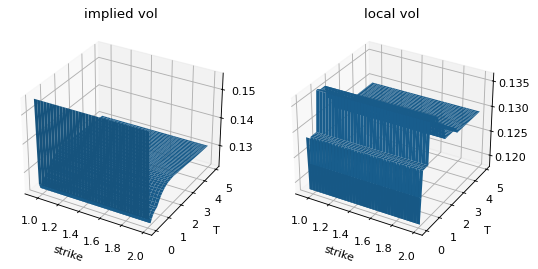

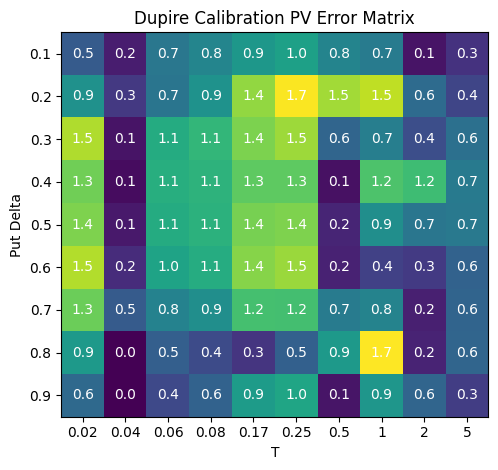

In [ ]:
S, r, q = 1.25805, 0.01, 0.0
iv = createTestImpliedVol(S, r, q, sc = 0.0, smileInterpMethod='CUBICSPLINE')
plotTestImpliedVolSurface(S, r, q, iv)
pdeCalibReport(S, r, q, iv)

Then test smile case with CubicSpline, with a mild smile (tuned by the coeffiicent sc)

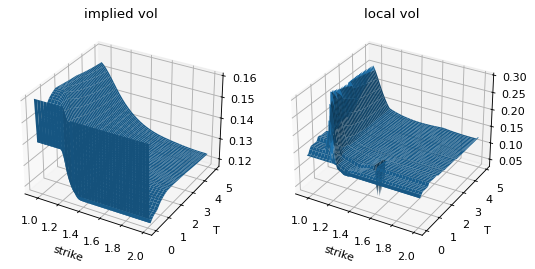

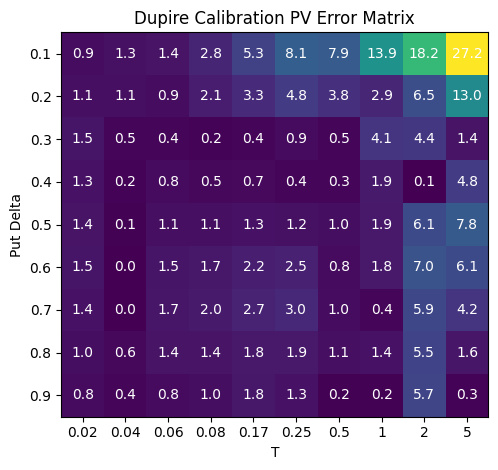

In [ ]:
iv = createTestImpliedVol(S, r, q, sc = 0.5, smileInterpMethod='CUBICSPLINE')
plotTestImpliedVolSurface(S, r, q, iv)
pdeCalibReport(S, r, q, iv)

Then test smile case with CubicSpline, with a the input smile (sc = 1.0). It can be seen that the short end low strike region has some smile arbitrage. The calibration errors become larger.

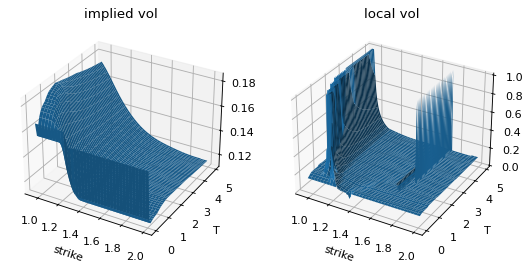

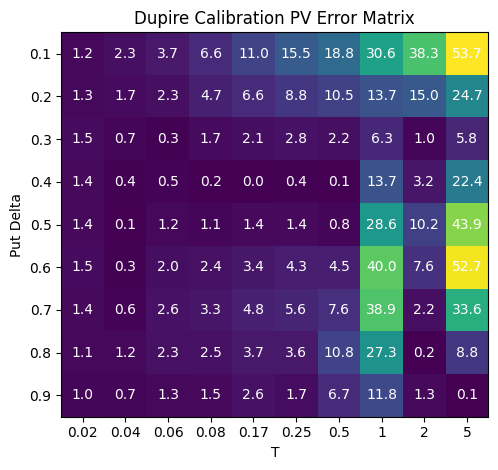

In [ ]:
iv = createTestImpliedVol(S, r, q, sc = 1.0, smileInterpMethod='CUBICSPLINE')
plotTestImpliedVolSurface(S, r, q, iv)
pdeCalibReport(S, r, q, iv)

***
#### Your test cases with SmileAF

     pcost       dcost       gap    pres   dres
 0:  5.7198e-02 -1.0808e+03  4e+03  2e+01  1e+02
 1:  5.7906e-02 -1.6949e+02  3e+02  1e+00  7e+00
 2:  5.9554e-02 -2.3830e+01  3e+01  1e-02  7e-02
 3:  5.9566e-02 -5.5094e-01  6e-01  3e-04  1e-03
 4:  5.9524e-02 -1.2177e-01  2e-01  6e-05  3e-04
 5:  5.9077e-02  3.3330e-02  3e-02  8e-06  5e-05
 6:  5.8502e-02  5.4875e-02  4e-03  9e-07  5e-06
 7:  5.8164e-02  5.7556e-02  6e-04  1e-07  6e-07
 8:  5.8034e-02  5.7915e-02  1e-04  1e-08  8e-08
 9:  5.7995e-02  5.7982e-02  1e-05  1e-09  7e-09
10:  5.7989e-02  5.7989e-02  3e-07  2e-11  9e-11
11:  5.7989e-02  5.7989e-02  4e-09  2e-13  1e-12
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  5.7489e-02 -7.1118e+02  3e+03  2e+01  9e+01
 1:  5.8115e-02 -1.1489e+02  2e+02  1e+00  5e+00
 2:  5.9474e-02 -1.3517e+01  1e+01  1e-02  5e-02
 3:  5.9460e-02 -4.8890e-01  6e-01  4e-04  2e-03
 4:  6.0231e-02 -1.4070e-01  2e-01  7e-05  3e-04
 5:  5.9925e-02  3.6837e-02  2e-02  7e-06  4e-0

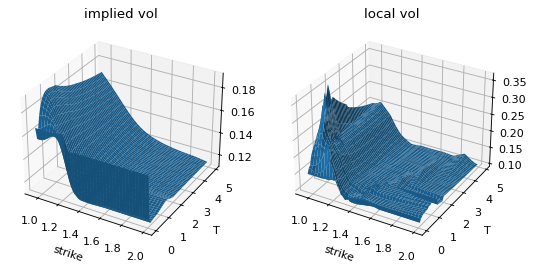

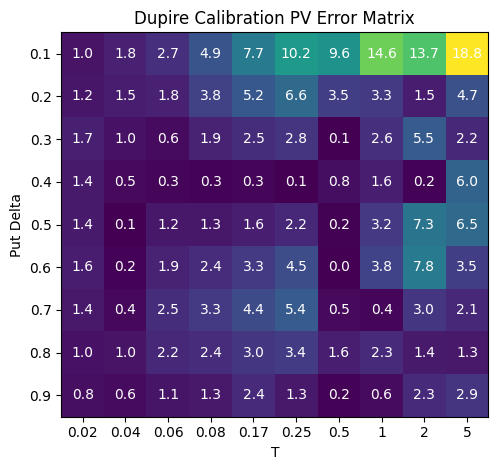

In [ ]:
S, r, q = 1.25805, 0.01, 0.0

iv = createTestImpliedVol(S, r, q, sc=1.0, smileInterpMethod='AF')
plotTestImpliedVolSurface(S, r, q, iv)
pdeCalibReport(S, r, q, iv)

## Conclusion and Improvements


     pcost       dcost       gap    pres   dres
 0:  5.7198e-02 -1.0808e+03  4e+03  2e+01  1e+02
 1:  5.7906e-02 -1.6949e+02  3e+02  1e+00  7e+00
 2:  5.9554e-02 -2.3830e+01  3e+01  1e-02  7e-02
 3:  5.9566e-02 -5.5094e-01  6e-01  3e-04  1e-03
 4:  5.9524e-02 -1.2177e-01  2e-01  6e-05  3e-04
 5:  5.9077e-02  3.3330e-02  3e-02  8e-06  5e-05
 6:  5.8502e-02  5.4875e-02  4e-03  9e-07  5e-06
 7:  5.8164e-02  5.7556e-02  6e-04  1e-07  6e-07
 8:  5.8034e-02  5.7915e-02  1e-04  1e-08  8e-08
 9:  5.7995e-02  5.7982e-02  1e-05  1e-09  7e-09
10:  5.7989e-02  5.7989e-02  3e-07  2e-11  9e-11
11:  5.7989e-02  5.7989e-02  4e-09  2e-13  1e-12
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  5.7489e-02 -7.1118e+02  3e+03  2e+01  9e+01
 1:  5.8115e-02 -1.1489e+02  2e+02  1e+00  5e+00
 2:  5.9474e-02 -1.3517e+01  1e+01  1e-02  5e-02
 3:  5.9460e-02 -4.8890e-01  6e-01  4e-04  2e-03
 4:  6.0231e-02 -1.4070e-01  2e-01  7e-05  3e-04
 5:  5.9925e-02  3.6837e-02  2e-02  7e-06  4e-0

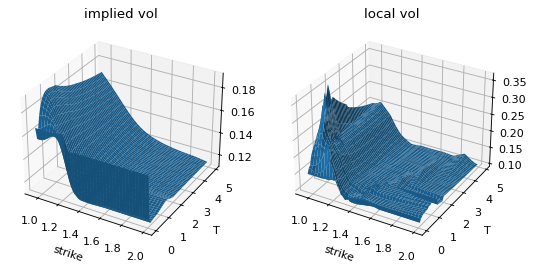

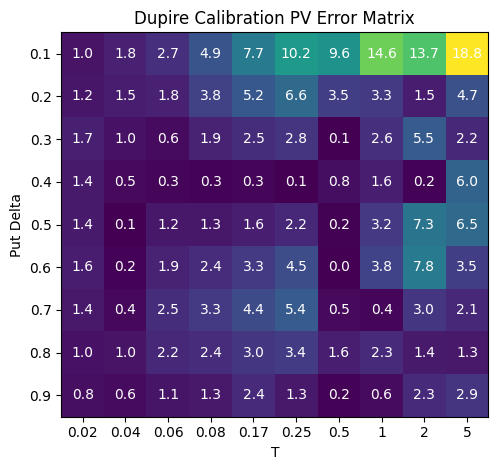

createTestImpliedVol runtime: 0.4302 seconds
plotTestImpliedVolSurface runtime: 3.9923 seconds
pdeCalibReport runtime: 126.3402 seconds
Total runtime: 130.7627 seconds


In [ ]:
import timeit

# Measure time for each function using timeit
createTestImpliedVol_time = timeit.timeit(lambda: createTestImpliedVol(S, r, q, sc=1.0, smileInterpMethod='AF'), number=1)
plotTestImpliedVolSurface_time = timeit.timeit(lambda: plotTestImpliedVolSurface(S, r, q, iv), number=1)
pdeCalibReport_time = timeit.timeit(lambda: pdeCalibReport(S, r, q, iv), number=1)

# Print the individual runtimes
print(f"createTestImpliedVol runtime: {createTestImpliedVol_time:.4f} seconds")
print(f"plotTestImpliedVolSurface runtime: {plotTestImpliedVolSurface_time:.4f} seconds")
print(f"pdeCalibReport runtime: {pdeCalibReport_time:.4f} seconds")

# Total time for the entire block
total_time = createTestImpliedVol_time + plotTestImpliedVolSurface_time + pdeCalibReport_time
print(f"Total runtime: {total_time:.4f} seconds")


The SmileAF approach has shown significant improvements over the cubic spline method in several key areas:

1. `Arbitrage Elimination`: The SmileAF method effectively removes arbitrage opportunities, particularly in regions with low strikes and longer maturities, which were problematic in the cubic spline method.

2. `Pricing Accuracy`: The SmileAF approach produces more accurate option prices, as evidenced by the smaller calibration errors in the PV Error Matrix. Additionally, the errors are more evenly distributed across various strikes and maturities, leading to a more reliable pricing model.

3. `Surface Stability`: The local volatility surface generated by SmileAF is notably more stable and realistic. Unlike the cubic spline method, it avoids extreme values, ensuring a smoother and more consistent volatility surface.

4.`Customization and Scalability`: SmileAF is scalable for large datasets and customizable for different market conditions, improving its suitability for diverse portfolios and strategies.

5. `Robustness`: It handles extreme market conditions better, ensuring a stable volatility surface during high volatility periods.

6. `Hedging & Risk Management`: The improved volatility surface enhances hedging strategies, reducing risk and transaction costs.

*`Performance Considerations`*: The time taken for the functions to run was as follows:

```
createTestImpliedVol: 0.4302 seconds

plotTestImpliedVolSurface: 3.9923 seconds

pdeCalibReport: 126.3402 seconds

Total runtime: 130.7627 seconds
```

To improve efficiency, parallelizing these functions across multiple threads could significantly reduce runtime, particularly for the more time-intensive pdeCalibReport function.

*`Error Matrix Improvements`*: The final error matrix demonstrates the effectiveness of constraint optimization, as the errors are considerably lower than with the cubic spline approach. This enhances the overall reliability and precision of the option pricing model.
